# Fine-Tuning a Pretrained CNN for Cat vs Dog Classification

## Objective

In this notebook, we will perform fine-tuning using a pretrained CNN model.

We will use MobileNetV2, which has already been trained on the ImageNet dataset.

The main goal is to understand:

- What fine-tuning is
- How pretrained models work
- How to freeze layers
- How to train a new classification head
- How to unfreeze selected layers
- How to fine-tune pretrained layers
- Why a small learning rate is used
- How to evaluate the final model

### Fine-Tuning Workflow

1. Load the dataset
2. Load the pretrained model
3. Freeze the pretrained layers
4. Add a new classification head
5. Train the classification head
6. Unfreeze selected upper layers
7. Recompile with a small learning rate
8. Fine-tune the model
9. Evaluate the model
10. Save the final model

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Dataset Paths

The dataset has already been divided into:

- Training data
- Validation data
- Test data

We will not create or split the dataset in this notebook.

The expected folder structure is:

PetImages_Split/
│
├── train/
│   ├── Cat/
│   └── Dog/
│
├── validation/
│   ├── Cat/
│   └── Dog/
│
└── test/
    ├── Cat/
    └── Dog/

In [2]:
from pathlib import Path
import random
from PIL import Image

SOURCE = Path(r"F:\Anas\Dataset\PetImages")
TARGET = Path(r"F:\Anas\Dataset\PetImages_100")

cat_source = SOURCE / "Cat"
dog_source = SOURCE / "Dog"

cat_target = TARGET / "Cat"
dog_target = TARGET / "Dog"

cat_target.mkdir(parents=True, exist_ok=True)
dog_target.mkdir(parents=True, exist_ok=True)

random.seed(42)

cat_images = [
    p for p in cat_source.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

dog_images = [
    p for p in dog_source.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

cats = random.sample(cat_images, 50)
dogs = random.sample(dog_images, 50)

# Remove old sample images
for folder in [cat_target, dog_target]:
    for file in folder.iterdir():
        if file.is_file():
            file.unlink()

# Save every image as RGB JPEG
for i, image_path in enumerate(cats):
    with Image.open(image_path) as img:
        img.convert("RGB").save(
            cat_target / f"cat_{i}.jpg",
            "JPEG"
        )

for i, image_path in enumerate(dogs):
    with Image.open(image_path) as img:
        img.convert("RGB").save(
            dog_target / f"dog_{i}.jpg",
            "JPEG"
        )

print("Done!")
print("Cat images:", len(list(cat_target.glob("*.jpg"))))
print("Dog images:", len(list(dog_target.glob("*.jpg"))))
print("Total:", len(list(cat_target.glob("*.jpg"))) +
      len(list(dog_target.glob("*.jpg"))))

Done!
Cat images: 50
Dog images: 50
Total: 100


In [3]:
DATA_DIR = Path(r"F:\Anas\Dataset\PetImages_100")

print(DATA_DIR.exists())
print(list(DATA_DIR.iterdir()))

True
[WindowsPath('F:/Anas/Dataset/PetImages_100/Cat'), WindowsPath('F:/Anas/Dataset/PetImages_100/Dog')]


In [4]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

## 3. Load the Datasets

TensorFlow's `image_dataset_from_directory()` automatically:

- Reads images from folders
- Detects class names
- Assigns numerical labels
- Resizes images
- Creates batches

Our two classes are:

- Cat
- Dog

In [5]:
import tensorflow as tf

DATA_DIR = Path(r"F:\Anas\Dataset\PetImages_100")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(224, 224),
    batch_size=16,
    shuffle=False,
    seed=42,
    validation_split=0.2,
    subset="validation"
)

Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.


In [6]:
class_names = train_dataset.class_names

print("Classes:", class_names)

Classes: ['Cat', 'Dog']


## 4. Display Sample Images

Before training the model, we should verify that the images and labels are being loaded correctly.

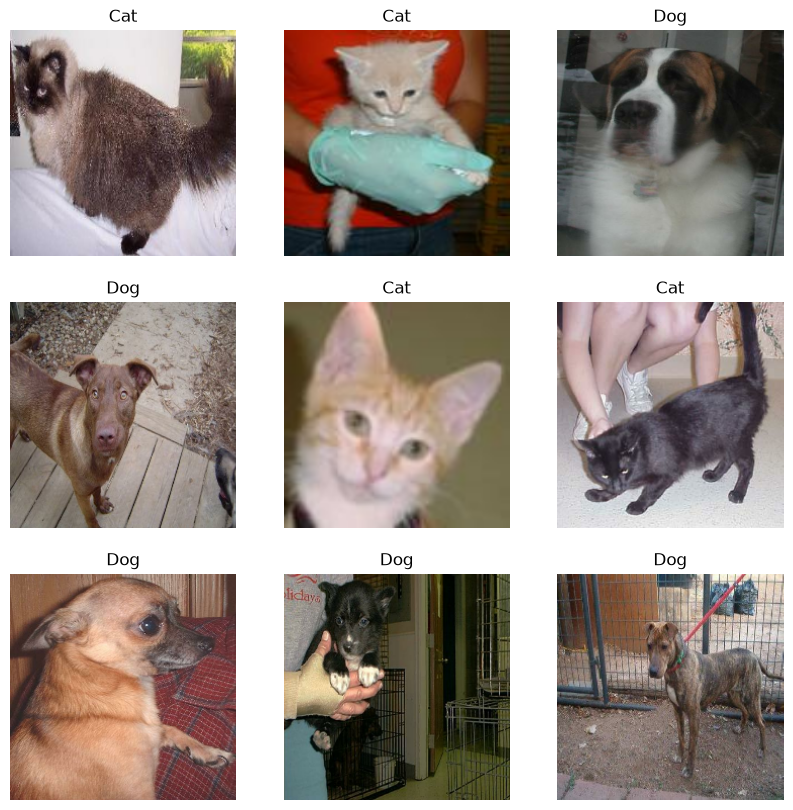

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## 5. Optimize the Dataset Pipeline

`prefetch()` allows TensorFlow to prepare the next batch while the model is processing the current batch.

This can improve training performance.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    AUTOTUNE
)

# 6. Data Augmentation

Our dataset is relatively small, so the model may overfit.

Data augmentation creates slightly different versions of training images.

Common techniques include:

- Horizontal flipping
- Rotation
- Zoom
- Contrast changes

The model therefore sees more variations of the same images.

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

# 7. Load the Pretrained Model

We will use MobileNetV2.

MobileNetV2 has already learned visual features from ImageNet.

Instead of training the CNN from random weights, we will start with these pretrained weights.

### Why MobileNetV2?

- Lightweight
- Fast
- Good for image classification
- Suitable for transfer learning
- Requires less computation than many larger CNN architectures

In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded successfully.")

MobileNetV2 loaded successfully.


# 8. Freeze the Pretrained Model

Initially, we freeze MobileNetV2.

A frozen layer does not have its weights updated during training.

At this stage:

MobileNetV2 → Frozen

New classification head → Trainable

This stage is commonly called feature extraction.

In [11]:
base_model.trainable = False

print(
    "Base model trainable:",
    base_model.trainable
)

Base model trainable: False


# 9. Build the Transfer Learning Model

We will add our own classification head on top of MobileNetV2.

Architecture:

Input Image
↓
Data Augmentation
↓
MobileNetV2
↓
Global Average Pooling
↓
Dropout
↓
Dense
↓
Sigmoid
↓
Cat / Dog

In [12]:
inputs = tf.keras.Input(
    shape=IMG_SIZE + (3,)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

# 10. Model Summary

The model consists of:

- Input layer
- Data augmentation
- Pretrained MobileNetV2
- Global Average Pooling
- Dropout
- Binary classification layer

The MobileNetV2 base is currently frozen.

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

# 13. Train the Classification Head

At this stage:

MobileNetV2 → Frozen

Classification Head → Trainable

The pretrained CNN extracts features while our new classifier learns how to distinguish cats from dogs.

In [17]:
history_initial = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.6625 - loss: 0.6185 - val_accuracy: 0.6000 - val_loss: 0.5034 - learning_rate: 0.0010
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.7625 - loss: 0.4972 - val_accuracy: 0.8500 - val_loss: 0.4008 - learning_rate: 0.0010
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.8750 - loss: 0.3501 - val_accuracy: 0.9000 - val_loss: 0.3176 - learning_rate: 0.0010
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.9125 - loss: 0.2952 - val_accuracy: 0.9500 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.9375 - loss: 0.2360 - val_accuracy: 0.9500 - val_loss: 0.2680 - learning_rate: 0.0010


# Fine-Tuning the Pretrained Model

In the previous stage, the pretrained MobileNetV2 model was frozen and only the new classification head was trained.

Now we will perform **fine-tuning**.

Fine-tuning means:
- Unfreezing some layers of the pretrained model
- Keeping the early layers frozen
- Training the later layers on our Cat vs Dog dataset
- Using a very small learning rate

The goal is to allow MobileNetV2 to learn features that are more specific to our Cat vs Dog classification task.

## Why Do We Fine-Tune?

The pretrained MobileNetV2 model was originally trained on ImageNet, which contains many different types of objects.

Its early layers have already learned general features such as:

- Edges
- Lines
- Shapes
- Textures
- Colors

The deeper layers contain more task-specific visual features.

Therefore, instead of retraining the entire network from scratch, we keep the early layers frozen and train some of the later layers.

This allows the model to adapt the pretrained features to our Cat vs Dog dataset.

In [18]:
base_model.trainable = True

print("Base model trainable:", base_model.trainable)

Base model trainable: True


## Freeze Early Layers and Unfreeze Later Layers

We do not want to train every layer of MobileNetV2.

The early layers contain useful general-purpose features, so we keep them frozen.

We will fine-tune only the later layers.

This reduces the number of trainable parameters and helps prevent overfitting, especially because our dataset is small.

In [19]:
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Fine-tuning starts from layer:", fine_tune_at)

Fine-tuning starts from layer: 100


In [20]:
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Batch Normalization layers have been frozen.")

Batch Normalization layers have been frozen.


## Check Trainable and Non-Trainable Layers

Before training, we can check how many layers are trainable.

Only the later layers of MobileNetV2 should be trainable, while the early layers remain frozen.

In [21]:
trainable_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

frozen_layers = sum(
    1 for layer in base_model.layers if not layer.trainable
)

print("Trainable layers:", trainable_layers)
print("Frozen layers:", frozen_layers)

Trainable layers: 36
Frozen layers: 118


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 333ms/step - accuracy: 0.9250 - loss: 0.1861 - val_accuracy: 0.9500 - val_loss: 0.1879 - learning_rate: 1.0000e-05
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.9750 - loss: 0.1366 - val_accuracy: 0.9500 - val_loss: 0.1665 - learning_rate: 1.0000e-05
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.9750 - loss: 0.1308 - val_accuracy: 0.9500 - val_loss: 0.1197 - learning_rate: 1.0000e-05
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.9875 - loss: 0.0670 - val_accuracy: 1.0000 - val_loss: 0.0751 - learning_rate: 1.0000e-05
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.9750 - loss: 0.0877 - val_accuracy: 1.0000 - val_loss: 0.0666 - learning_rate: 1.0000e-05


In [24]:
print("Fine-Tuning Accuracy:",
      history_fine.history["accuracy"][-1])

print("Fine-Tuning Validation Accuracy:",
      history_fine.history["val_accuracy"][-1])

print("Fine-Tuning Loss:",
      history_fine.history["loss"][-1])

print("Fine-Tuning Validation Loss:",
      history_fine.history["val_loss"][-1])

Fine-Tuning Accuracy: 0.9750000238418579
Fine-Tuning Validation Accuracy: 1.0
Fine-Tuning Loss: 0.0876738578081131
Fine-Tuning Validation Loss: 0.06663898378610611


## Fine-Tuning Complete

The MobileNetV2 model has now been fine-tuned for Cat vs Dog classification.

The model has adapted some of its pretrained visual features to our specific dataset.

The next step is to evaluate the final model on the test dataset and calculate:

- Test Loss
- Test Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix